In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
df=pd.read_csv("titanic.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
#code for dropping duplicating value
df = df.drop_duplicates()

In [8]:
#rechecking duplicate values
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [9]:
df = df.drop(columns=['Cabin'])

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# One-hot encode 'Embarked' column
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [12]:
survival_counts = df['Survived'].value_counts()

print("Survival Counts:\n", survival_counts)

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
# Encode gender (Male=1, Female=0)
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [15]:
X = df.drop(["Survived", "Name", "Ticket"], axis=1)
y = df["Survived"]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
log_reg = LogisticRegression(solver='liblinear') # Added solver for convergence
log_reg.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [20]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
y_pred_log = log_reg.predict(X_test)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Not Survived","Survived"]))


Logistic Regression Results
Accuracy: 0.7985074626865671
              precision    recall  f1-score   support

Not Survived       0.81      0.86      0.83       157
    Survived       0.78      0.71      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



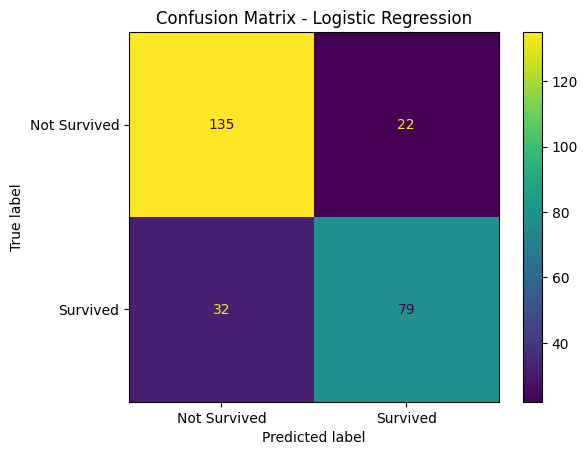

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [22]:
new_data = [[0, 3, 1, 22.0, 1, 0, 7.25, 0, 0]]

# Column names must match training data
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# Predict again
log_result = log_reg.predict(new_data_df)[0]

# Revert display mapping to standard interpretation: 0 -> "Not Survived", 1 -> "Survived"
display_mapping = {0: "Not Survived", 1: "Survived"}

print("Logistic Regression Prediction:", display_mapping[log_result])

Logistic Regression Prediction: Not Survived
